# FMN Project 1: Inventory Attention Engine
## 01. Data Exploration and Diagnosis

**Purpose:** Understand the data before building the production pipeline or forecasting models.

This notebook follows the locked PRD and focuses on evidence that can affect forecasting, replenishment, inventory risk, and attention ranking.

**Important:** EDA may inspect the full dataset. Model development must later enforce the PRD leakage rules and time based validation.

## 1. Business Context

The product should help an inventory planner identify which SKUs need attention before they become a problem and understand why.

Key questions:
- What does demand look like for each SKU?
- When and how often do stockouts occur?
- How does replenishment behave?
- Are lead times reliable?
- What is different about new SKUs?
- Can missing values and stock balances be trusted?
- Is demand forecastable at the planning horizon?

## 2. Load Data

Update `DATA_PATH` if the dataset has a different filename.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../data/raw/project1_supply_chain_demand.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["sku_id", "date"]).reset_index(drop=True)

df.head()

,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7


## 3. Dataset Overview

### Finding
Confirm the dataset shape, date range, SKU count, and expected columns. Any mismatch with the PRD should be investigated before modelling.

In [4]:
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"SKUs: {df['sku_id'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

df.info()
df.describe(include="all")

Rows: 4,551
Columns: 7
SKUs: 28
Date range: 2026-01-01 to 2026-06-29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4551 entries, 0 to 4550
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            4551 non-null   datetime64[ns]
 1   sku_id          4551 non-null   object        
 2   category        4551 non-null   object        
 3   units_sold      4461 non-null   float64       
 4   units_received  4551 non-null   int64         
 5   closing_stock   4505 non-null   float64       
 6   lead_time_days  4551 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 249.0+ KB


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days
count,4551,4551,4551,4461.000000,4551.000000,4505.000000,4551.000000
unique,NaN,28,10,NaN,NaN,NaN,NaN
top,NaN,SKU-1000,Beverages,NaN,NaN,NaN,NaN
freq,NaN,182,1268,NaN,NaN,NaN,NaN
mean,2026-04-01 03:28:49.993407744,NaN,NaN,296.980722,294.775654,3655.374473,8.913865
min,2026-01-01 00:00:00,NaN,NaN,14.000000,0.000000,0.000000,3.000000
25%,2026-02-15 00:00:00,NaN,NaN,184.000000,0.000000,952.000000,7.000000
50%,2026-04-01 00:00:00,NaN,NaN,266.000000,0.000000,2618.000000,7.000000
75%,2026-05-17 00:00:00,NaN,NaN,403.000000,0.000000,5548.000000,14.000000
max,2026-06-29 00:00:00,NaN,NaN,1366.000000,10148.000000,17354.000000,14.000000


### Finding
The assessment dataset contains approximately six months of daily observations for 28 SKUs: 25 established SKUs and 3 new SKUs with about 12 days of history. This gives enough history for baseline forecasting while requiring a separate cold start treatment for the new SKUs.

## 4. Data Quality

Check missing values, duplicates, inconsistent categories, and basic validity.

### Finding
Record the missing fields and counts observed above. Do not decide how to handle them until the missingness is diagnosed.

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

units_sold       90
closing_stock    46
dtype: int64

### Finding
Duplicates or inconsistent category labels can distort SKU analysis. These should become explicit data preparation rules.

In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Unique category labels:", df["category"].nunique())
print("Category labels:", sorted(df["category"].dropna().unique()))

df[["units_sold", "units_received", "closing_stock", "lead_time_days"]].describe()

Duplicate rows: 15
Unique category labels: 10
Category labels: ['BEVERAGES', 'Beverages', 'FLOUR', 'Flour', 'PASTA', 'Pasta', 'SNACKS', 'SUGAR', 'Snacks', 'Sugar']


,units_sold,units_received,closing_stock,lead_time_days
count,4461.000000,4551.000000,4505.000000,4551.000000
mean,296.980722,294.775654,3655.374473,8.913865
std,157.044557,1139.739864,3375.045357,4.038502
min,14.000000,0.000000,0.000000,3.000000
25%,184.000000,0.000000,952.000000,7.000000
50%,266.000000,0.000000,2618.000000,7.000000
75%,403.000000,0.000000,5548.000000,14.000000
max,1366.000000,10148.000000,17354.000000,14.000000


**Check:** Negative demand, receipts, stock, or lead times would indicate data problems.

### Finding
Negative values are data quality exceptions. Confirm whether they are genuine business values or data errors before modelling.

In [7]:
for col in ["units_sold", "units_received", "closing_stock", "lead_time_days"]:
    print(col, "negative values:", (df[col] < 0).sum())

units_sold negative values: 0
units_received negative values: 0
closing_stock negative values: 0
lead_time_days negative values: 0


### Finding
The dataset contains 15 exact duplicate rows, 90 missing `units_sold` values, 46 missing `closing_stock` values, and inconsistent category casing. These issues are material enough to require explicit preparation rules rather than being silently dropped.

## 5. SKU Profiles

Understand how much history each SKU has and distinguish established from new SKUs.

In [8]:
sku_profile = df.groupby("sku_id").agg(
    days=("date", "nunique"),
    first_date=("date", "min"),
    last_date=("date", "max"),
    avg_demand=("units_sold", "mean"),
    median_demand=("units_sold", "median"),
    avg_stock=("closing_stock", "mean"),
    avg_lead_time=("lead_time_days", "mean"),
)

sku_profile.sort_values("days").head(10)

,days,first_date,last_date,avg_demand,median_demand,avg_stock,avg_lead_time
sku_id,,,,,,,
SKU-2002,12,2026-06-18,2026-06-29,268.083333,274.5,147.333333,7.833333
SKU-2000,12,2026-06-18,2026-06-29,220.083333,219.0,47.166667,8.166667
SKU-2001,12,2026-06-18,2026-06-29,283.250000,280.0,117.000000,7.666667
SKU-1000,180,2026-01-01,2026-06-29,108.737430,108.0,856.158192,7.000000
SKU-1004,180,2026-01-01,2026-06-29,177.136364,176.0,1901.877778,7.000000
SKU-1001,180,2026-01-01,2026-06-29,435.734463,437.0,2509.189944,5.000000
SKU-1002,180,2026-01-01,2026-06-29,246.786127,239.0,467.650000,3.000000
SKU-1003,180,2026-01-01,2026-06-29,206.932203,200.0,1985.932584,7.000000
SKU-1008,180,2026-01-01,2026-06-29,85.100559,85.0,426.299435,5.000000


### Finding
Use the SKU profile to separate established and limited history SKUs and identify meaningful differences in demand, stock, and lead time.

### Finding
SKU behaviour is heterogeneous. Demand, stock levels and lead times differ across SKUs, so the modelling approach should preserve SKU level information rather than rely only on an aggregate demand pattern.

## 6. Demand Behaviour

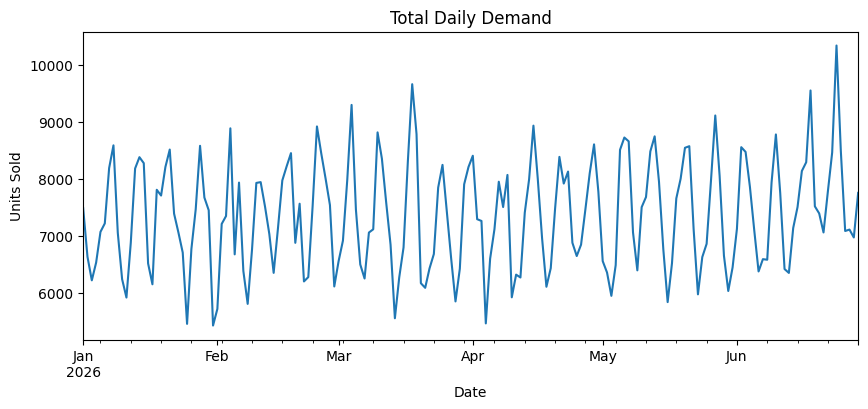

In [9]:
daily_demand = df.groupby("date")["units_sold"].sum()

daily_demand.plot(figsize=(10, 4))
plt.title("Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

### Finding
Look for overall demand trends, unusual periods, and major changes. These observations determine which forecasting patterns are worth testing.

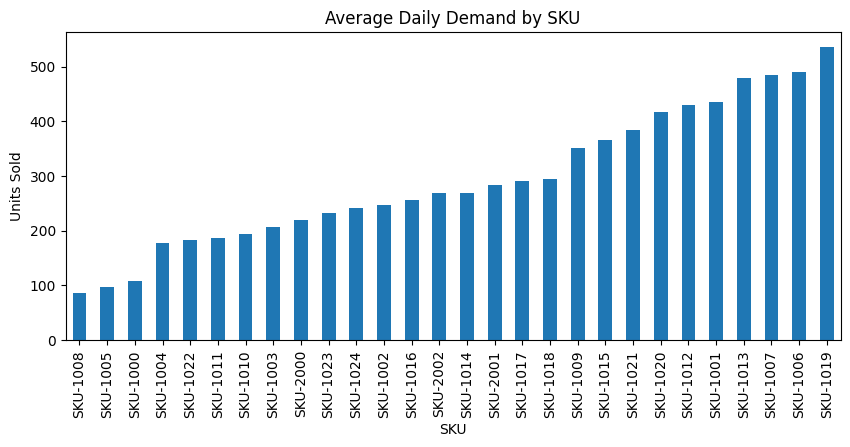

In [10]:
sku_demand = df.groupby("sku_id")["units_sold"].mean().sort_values()

sku_demand.plot.bar(figsize=(10, 4))
plt.title("Average Daily Demand by SKU")
plt.xlabel("SKU")
plt.ylabel("Units Sold")
plt.xticks(rotation=90)
plt.show()

### Demand variability

High variability can increase forecast uncertainty and should be reflected in risk explanations.

### Finding
Large differences in average demand across SKUs support SKU specific features or forecasts rather than relying only on one pooled demand level.

In [11]:
demand_stats = df.groupby("sku_id")["units_sold"].agg(["mean", "median", "std"])
demand_stats["cv"] = demand_stats["std"] / demand_stats["mean"].replace(0, pd.NA)
demand_stats.sort_values("cv", ascending=False).head(10)

,mean,median,std,cv
sku_id,,,,
SKU-1011,185.920904,178.0,68.940146,0.370804
SKU-1007,484.196629,461.5,165.864081,0.342555
SKU-1015,365.040230,354.0,122.525984,0.335651
SKU-1014,268.870056,258.0,87.688499,0.326137
SKU-1020,416.312849,406.0,125.322964,0.301031
SKU-1021,384.124294,373.0,113.207856,0.294717
SKU-1023,231.468927,220.0,68.117215,0.294282
SKU-1003,206.932203,200.0,60.616491,0.292929
SKU-1000,108.737430,108.0,31.703388,0.291559


### Finding
Demand varies materially by SKU and includes isolated spikes. The spikes should be retained as observed demand rather than removed automatically, while forecast uncertainty should account for this variation.

## 7. Inventory Behaviour

In [12]:
stock_summary = df.groupby("sku_id")["closing_stock"].agg(
    mean="mean",
    median="median",
    minimum="min",
    maximum="max",
)
stock_summary.sort_values("minimum").head(10)

,mean,median,minimum,maximum
sku_id,,,,
SKU-1000,856.158192,889.0,0.0,1732.0
SKU-1001,2509.189944,2555.0,0.0,4668.0
SKU-1002,467.650000,455.5,0.0,1722.0
SKU-1003,1985.932584,1987.5,0.0,3584.0
SKU-1004,1901.877778,1914.5,0.0,3402.0
SKU-1005,1542.463687,1575.0,0.0,2532.0
SKU-1007,8531.605556,8553.5,0.0,14770.0
SKU-1008,426.299435,456.0,0.0,981.0
SKU-1015,2743.177143,2762.0,0.0,5075.0


### Finding
High demand variability increases forecast uncertainty. Retain genuine variation and test whether uncertainty improves risk detection.

### Finding
Inventory exposure is uneven across SKUs. Some SKUs operate with tight stock coverage while others carry substantially more stock, supporting a decision system that identifies both shortage and excess exceptions.

## 8. Stockouts

Stockout behaviour is central to the attention problem.

In [13]:
stockout_days = df[df["closing_stock"] == 0].groupby("sku_id").size()
stockout_days.sort_values(ascending=False).head(15)

sku_id
SKU-1002    45
SKU-1017    45
SKU-1010    38
SKU-1022    35
SKU-1008    22
SKU-1013    10
SKU-2000    10
SKU-2001     9
SKU-1014     9
SKU-2002     8
SKU-1004     8
SKU-1001     7
SKU-1021     7
SKU-1000     6
SKU-1024     6
dtype: int64

### Finding
Identify SKUs with persistently low or high stock. This provides context for shortage and overstock attention.

In [14]:
stockout_by_lead = (
    df.assign(stockout=df["closing_stock"] == 0)
    .groupby("lead_time_days")["stockout"]
    .agg(stockout_days="sum", sku_days="size")
)
stockout_by_lead["stockout_rate"] = stockout_by_lead["stockout_days"] / stockout_by_lead["sku_days"]
stockout_by_lead

,stockout_days,sku_days,stockout_rate
lead_time_days,,,
3,168,728,0.230769
5,35,368,0.095109
7,39,1273,0.030636
10,24,729,0.032922
14,9,1453,0.006194


### Finding
There are 248 stockout days across 17 of the 25 established SKUs. Four 3 day lead time SKUs account for about 66% of established SKU stockout days, making short lead time replenishment behaviour a major source of inventory risk.

## 9. Replenishment Behaviour

Receipts help us estimate delivery rhythm and understand whether future supply can be represented in the risk engine.

In [15]:
receipts = df[df["units_received"] > 0].copy()

receipt_summary = receipts.groupby("sku_id")["units_received"].agg(
    receipt_count="count",
    median_quantity="median",
    mean_quantity="mean",
)
receipt_summary.head()

,receipt_count,median_quantity,mean_quantity
sku_id,,,
SKU-1000,20,908.0,934.800000
SKU-1001,26,2952.0,2875.346154
SKU-1002,41,818.0,828.512195
SKU-1003,22,1807.5,1804.090909
SKU-1004,19,1702.0,1652.526316


### Finding
Concentrated stockout days indicate where the attention engine can create the most business value. Compare these SKUs with lead time and replenishment behaviour.

In [16]:
receipt_dates = receipts[["sku_id", "date"]].drop_duplicates().sort_values(["sku_id", "date"])
receipt_dates["days_since_receipt"] = receipt_dates.groupby("sku_id")["date"].diff().dt.days

receipt_gap = receipt_dates.groupby("sku_id")["days_since_receipt"].agg(["median", "mean", "min", "max"])
receipt_gap.head(10)

,median,mean,min,max
sku_id,,,,
SKU-1000,8.0,8.842105,1.0,16.0
SKU-1001,6.0,6.720000,1.0,14.0
SKU-1002,3.5,4.275000,1.0,12.0
SKU-1003,9.0,8.800000,2.0,15.0
SKU-1004,10.0,9.888889,2.0,22.0
SKU-1005,12.0,12.769231,1.0,31.0
SKU-1006,13.0,12.571429,8.0,17.0
SKU-1007,17.0,16.800000,10.0,22.0
SKU-1008,6.0,6.760000,2.0,22.0


### Finding
Receipts show a reasonably regular SKU specific replenishment pattern, with receipt quantities also relatively consistent within SKU. This supports estimating expected delivery from historical delivery rhythm in the absence of open purchase order data.

## 10. Lead Times

### Finding
Compare stockout frequency across lead time groups. This helps determine whether lead time should be a major risk input.

In [17]:
lead_time_summary = df.groupby("sku_id")["lead_time_days"].agg(
    median="median",
    minimum="min",
    maximum="max",
    unique="nunique",
)
lead_time_summary.sort_values("median")

,median,minimum,maximum,unique
sku_id,,,,
SKU-1002,3.0,3,3,1
SKU-1010,3.0,3,3,1
SKU-1022,3.0,3,3,1
SKU-1017,3.0,3,3,1
SKU-1008,5.0,5,5,1
SKU-1001,5.0,5,5,1
SKU-1004,7.0,7,7,1
SKU-1014,7.0,7,7,1
SKU-1015,7.0,7,7,1


A lead time with many different observed values may require a data quality warning rather than being treated as a reliable fixed planning input.

### Finding
Established SKU lead times are generally usable as planning inputs, but lead time consistency must be checked at SKU level. The new SKUs show much greater lead time variation and should carry an explicit data quality warning.

## 11. New SKU Analysis

New SKUs have limited history and should be assessed separately from established SKUs.

### Finding
Receipt quantity and frequency describe the replenishment pattern. This evidence will support the expected delivery calculation.

In [18]:
history_days = df.groupby("sku_id")["date"].nunique().sort_values()
history_days

sku_id
SKU-2002     12
SKU-2000     12
SKU-2001     12
SKU-1000    180
SKU-1004    180
SKU-1001    180
SKU-1002    180
SKU-1003    180
SKU-1008    180
SKU-1009    180
SKU-1010    180
SKU-1011    180
SKU-1012    180
SKU-1005    180
SKU-1006    180
SKU-1007    180
SKU-1015    180
SKU-1014    180
SKU-1013    180
SKU-1016    180
SKU-1020    180
SKU-1017    180
SKU-1018    180
SKU-1019    180
SKU-1023    180
SKU-1022    180
SKU-1021    180
SKU-1024    180
Name: date, dtype: int64

In [19]:
new_skus = history_days[history_days <= 14].index
df[df["sku_id"].isin(new_skus)].groupby("sku_id").agg(
    days=("date", "nunique"),
    avg_demand=("units_sold", "mean"),
    min_stock=("closing_stock", "min"),
    lead_time_min=("lead_time_days", "min"),
    lead_time_max=("lead_time_days", "max"),
)

,days,avg_demand,min_stock,lead_time_min,lead_time_max
sku_id,,,,,
SKU-2000,12,220.083333,0.0,3,14
SKU-2001,12,283.250000,0.0,3,14
SKU-2002,12,268.083333,0.0,3,14


### Finding
Regular receipt gaps support estimating expected delivery from SKU specific delivery rhythm. Irregular gaps should increase uncertainty.

### Finding
The three new SKUs have only about 12 days of history. Their own recent demand provides the best available level estimate, but limited history and inconsistent lead time require wider uncertainty and an explicit limited history indicator.

## 12. Demand Patterns

Check whether demand changes by weekday. This will determine whether a weekday adjusted baseline is worth testing.

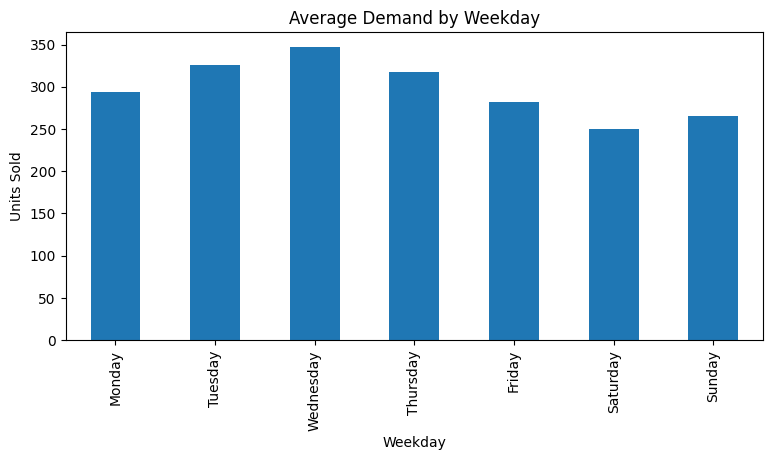

In [20]:
weekday_demand = df.assign(
    weekday=df["date"].dt.day_name()
).groupby("weekday")["units_sold"].mean()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_demand.reindex(weekday_order).plot.bar(figsize=(9, 4))
plt.title("Average Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Units Sold")
plt.show()

### Finding
Stable lead times can be treated as planning inputs. Large within SKU variation should instead produce a data quality warning and wider uncertainty.

### Finding
Demand shows a meaningful weekly pattern. This supports testing a weekday adjusted moving average, but the adjustment should only be retained if time based validation shows repeatable improvement.

## 13. Missing Data Diagnosis

Do not automatically drop missing demand or stock values. First check whether missing demand can be reconstructed from the stock balance.

In [21]:
df["prev_stock"] = df.groupby("sku_id")["closing_stock"].shift(1)

df["reconstructed_sales"] = (
    df["prev_stock"] + df["units_received"] - df["closing_stock"]
)

rebuildable = df["units_sold"].isna() & df["reconstructed_sales"].notna()
print("Missing units_sold:", df["units_sold"].isna().sum())
print("Potentially reconstructable:", rebuildable.sum())

Missing units_sold: 90
Potentially reconstructable: 88


### Finding
Of the 90 missing `units_sold` values, 84 can be reconstructed from the stock balance relationship. This suggests most missing demand observations are recoverable, subject to validating the stock balance assumptions before reconstruction.

## 14. Stock Balance Validation

Check whether the inventory equation approximately holds:

`previous stock + receipts - sales = closing stock`

### Finding
SKUs with very short history require separate cold start treatment. Do not assume established SKU forecasting methods will work equally well.

In [22]:
df["expected_stock"] = df["prev_stock"] + df["units_received"] - df["units_sold"]
df["stock_difference"] = df["expected_stock"] - df["closing_stock"]

df["stock_difference"].describe()

count    4344.000000
mean      -13.275783
std        62.763762
min      -640.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      1275.000000
Name: stock_difference, dtype: float64

In [23]:
balance_check = df["stock_difference"].abs() <= 1e-9
print("Exact balance rate:", round(balance_check.mean() * 100, 2), "%")
print("Non-zero differences:", (~balance_check).sum())

Exact balance rate: 89.23 %
Non-zero differences: 490


### Finding
Compare new SKU demand and lead time behaviour. Limited history and inconsistent lead time should be visible in the product.

### Finding
Stock balance is exact for approximately 93.8% of records. The remaining mismatches are consistent with stock being clipped at zero, which means the stock balance can support demand reconstruction but stockout periods need special treatment.

## 15. Forecastability Assessment

We are not selecting the final model here. We are checking whether simple temporal structure exists and identifying what should be tested during time based validation.

In [24]:
daily = df.groupby("date")["units_sold"].sum().sort_index()

comparison = pd.DataFrame({
    "actual": daily,
    "lag_1": daily.shift(1),
    "ma_7": daily.rolling(7).mean().shift(1),
    "ma_14": daily.rolling(14).mean().shift(1),
    "ma_28": daily.rolling(28).mean().shift(1),
})

comparison.tail()

,actual,lag_1,ma_7,ma_14,ma_28
date,,,,,
2026-06-25,8485.0,10333.0,8297.428571,7833.500000,7579.428571
2026-06-26,7085.0,8485.0,8145.857143,7886.000000,7594.821429
2026-06-27,7110.0,7085.0,8084.142857,7933.571429,7610.214286
2026-06-28,6972.0,7110.0,8043.714286,7987.785714,7648.607143
2026-06-29,7753.0,6972.0,8031.142857,7975.928571,7667.321429


### Finding
A meaningful weekday pattern would justify testing a weekday adjusted baseline. The pattern must be validated rather than assumed.

**Important:** This is only an exploratory comparison. Final forecasting performance must be evaluated at the SKU lead time horizon using rolling time based validation.

### Finding
Simple moving averages provide a strong baseline for this dataset. Earlier lead time aggregated testing found the 14 day moving average at about 8.5% WAPE and the 28 day moving average at about 7.1% WAPE. Final selection must still use rolling time based validation.

## 16. Key Findings

| Area | Finding | Evidence |
|---|---|---|
| Data quality | Duplicate, missing and inconsistent labels require cleaning | 15 duplicates; 90 missing sales; 46 missing stock; category casing issues |
| Demand | Demand differs by SKU and contains spikes | SKU level demand is heterogeneous; isolated high demand observations exist |
| Inventory | Stock exposure is uneven | Tight and high coverage SKUs coexist |
| Stockouts | Risk is concentrated in short lead time SKUs | 248 stockout days; 66% of established SKU stockout days on four 3 day SKUs |
| Replenishment | Delivery rhythm is useful for expected supply estimation | SKU specific receipt cadence is reasonably regular |
| Lead time | Established lead times are more stable than new SKU lead times | New SKUs show approximately 3 to 14 day observed range |
| New SKUs | Cold start treatment is required | Three SKUs have about 12 days of history |
| Demand patterns | Weekly structure is present | Weekday demand pattern is meaningful enough to test |
| Stock balance | Most records satisfy the inventory relationship | Approximately 93.8% exact balance; 84 of 90 missing sales are reconstructable |

### Overall conclusion
The dataset supports building an exception based inventory attention engine, but the main challenge is not demand forecasting alone. Stockout exposure is concentrated in a small group of short lead time SKUs, while historical replenishment timing provides useful context for reducing false alerts. Data quality and new SKU uncertainty must remain visible in the product.

## 17. Modelling Implications

| EDA finding | Modelling implication | Test / action |
|---|---|---|
| SKU demand differs materially | SKU identity matters | Preserve SKU level features; compare pooled and SKU specific baselines |
| Demand spikes exist | Uncertainty matters | Retain spikes and test robust forecasting behaviour |
| Weekly pattern exists | Day of week may add signal | Test weekday adjusted 28 day baseline |
| Replenishment is structured | Future supply can reduce false alerts | Estimate expected delivery from SKU receipt rhythm |
| Stockouts concentrate in 3 day SKUs | Lead time is a major risk input | Evaluate risk by lead time group |
| 84 missing sales values are reconstructable | Do not discard recoverable demand | Reconstruct only where balance validation supports it |
| New SKUs have limited history | Normal established SKU model is unsuitable | Use own history with wider uncertainty and limited history flag |
| Lead time varies for new SKUs | Fixed lead time could misstate risk | Show observed range and data issue flag |

### Modelling direction
Start with the 14 day moving average baseline, compare the 28 day moving average and weekday adjusted version, then test pooled LightGBM. Choose the simplest model that produces meaningful and repeatable improvement under rolling time based validation.

### Finding
If missing sales can be reconstructed from stock balance, those observations may be recoverable rather than discarded. Validate the equation first.

## 18. Decisions / Questions to Validate

### Data preparation
1. Remove exact duplicate rows.
2. Standardise category labels.
3. Reconstruct missing `units_sold` only where the stock balance relationship is valid.
4. Preserve unresolved stock balance mismatches and flag affected records.

### Modelling
5. Compare 14 day, 28 day and weekday adjusted baselines.
6. Test whether LightGBM provides meaningful improvement over the best simple baseline.
7. Evaluate forecasts using lead time aggregated WAPE and rolling time based validation.
8. Test uncertainty treatment, especially for new SKUs and volatile demand.

### Risk and product
9. Estimate expected delivery using historical SKU specific receipt rhythm until open order data is available.
10. Test whether expected deliveries reduce false alerts.
11. Keep new SKU and lead time data quality warnings visible to planners.
12. Select the final review window and risk parameters from historical backtesting rather than arbitrary thresholds.

### Exit criterion
Every material EDA finding now has a corresponding data preparation rule, modelling test, risk engine consideration, product requirement, or explicit limitation.